In [41]:
# ─────────────────────────────────────────────
#  CELL 1 — Imports & Load Data
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

root     = Path.cwd().parent
raw      = root / "Data" / "raw"
outputs  = root / "outputs"
outputs.mkdir(exist_ok=True)

matches  = pd.read_csv(raw / "wc_all_matches.csv")
golden   = pd.read_csv(raw / "fifa_world_cup_2026_golden_dataset.csv")
fixtures = pd.read_csv(raw / "wc_2026_fixtures.csv")
df_teams = pd.read_csv(raw / "wc_2026_teams.csv")
editions = pd.read_csv(raw / "wc_all_editions.csv")
scorers  = pd.read_csv(raw / "wc_top_scorers.csv")

print("Matches loaded:       ", matches.shape)
print("Golden dataset loaded:", golden.shape)
print("Fixtures loaded:      ", fixtures.shape)
print("Teams loaded:         ", df_teams.shape)

Matches loaded:        (184, 11)
Golden dataset loaded: (1176, 10)
Fixtures loaded:       (104, 15)
Teams loaded:          (48, 7)


In [42]:
# ─────────────────────────────────────────────
#  CELL 2 — Null Check
# ─────────────────────────────────────────────
print("Matches")
print(matches.isnull().sum())
print()
print("Golden Dataset")
print(golden.isnull().sum())

Matches
year        0
stage       0
team1       0
score1      0
score2      0
team2       0
venue       0
city        0
country     0
date        0
notes      82
dtype: int64

Golden Dataset
name                    0
team_name               0
group                   0
appearances             0
goals                   0
assists                 0
minutes                 0
total_contributions     0
contributions_per_90    0
efficiency_score        0
dtype: int64


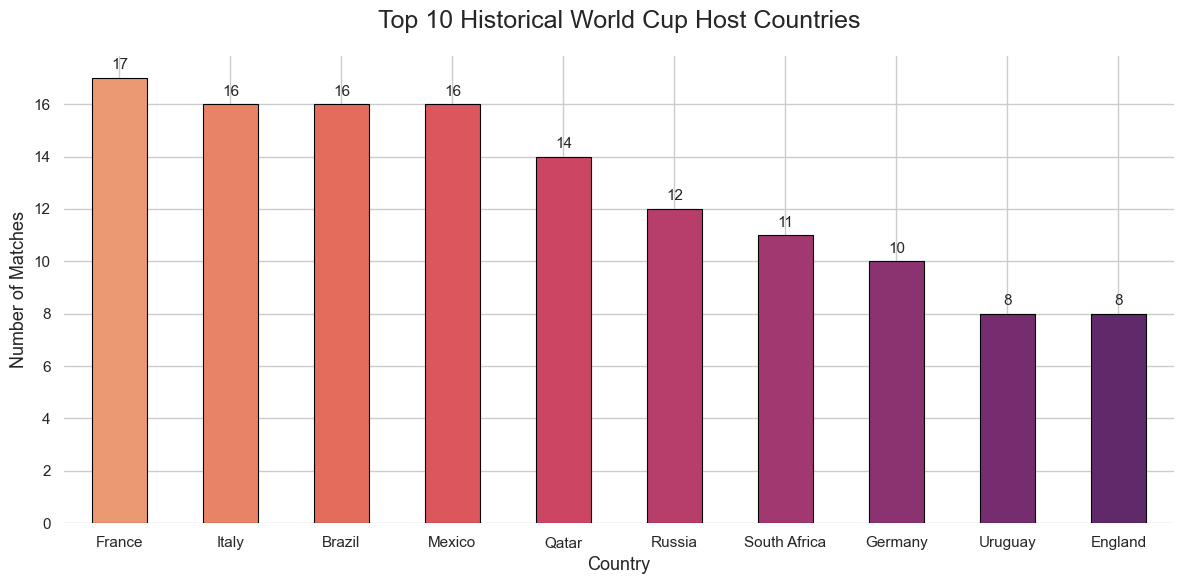

In [43]:
# ─────────────────────────────────────────────
#  CELL 3 — EDA: Top 10 Historical Participants
# ─────────────────────────────────────────────
top_teams = matches['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = top_teams.plot(
    kind="bar",
    color=sns.color_palette("flare", len(top_teams)),
    edgecolor="black",
    linewidth=0.8
)
ax.set_title("Top 10 Historical World Cup Host Countries", fontsize=18, pad=20)
ax.set_ylabel("Number of Matches", fontsize=13)
ax.set_xlabel("Country", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}" for v in container.datavalues],
                 padding=4, fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(outputs / "eda_participants.png", dpi=150, bbox_inches='tight')
plt.show()

Top 5 Most Efficient Teams for 2026:
team_name
Portugal    0.331154
France      0.305600
Brazil      0.267083
Morocco     0.266897
Germany     0.261200
Name: efficiency_score, dtype: float64


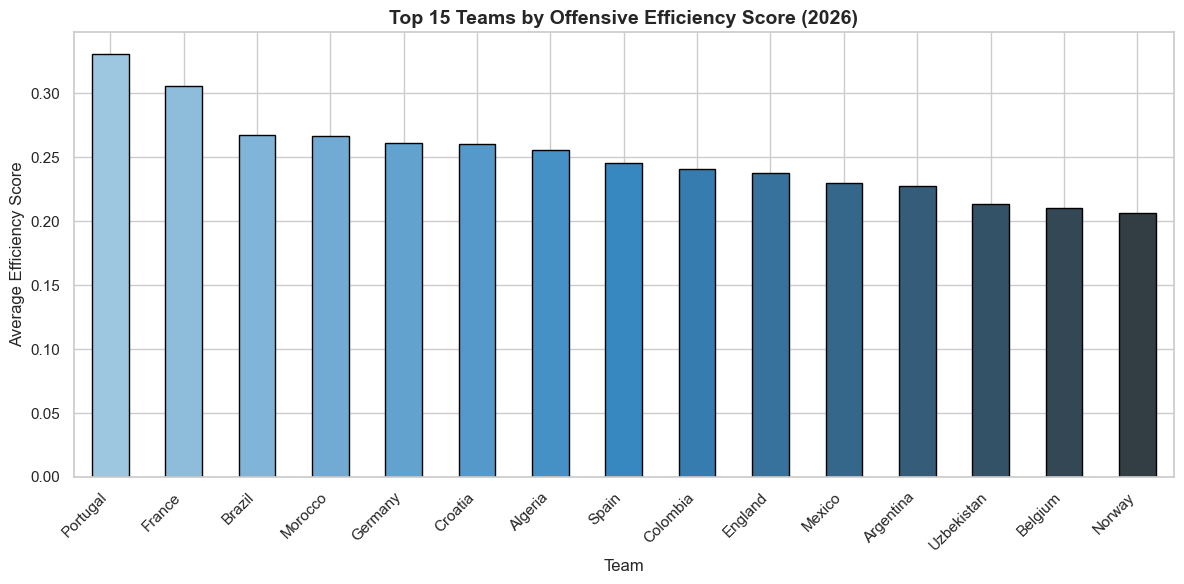

In [44]:
# ─────────────────────────────────────────────
#  CELL 4 — EDA: 2026 Offensive Efficiency
# ─────────────────────────────────────────────
team_efficiency = golden.groupby('team_name')['efficiency_score'].mean().sort_values(ascending=False)

print("Top 5 Most Efficient Teams for 2026:")
print(team_efficiency.head(5))

plt.figure(figsize=(12, 6))
team_efficiency.head(15).plot(kind='bar',
    color=sns.color_palette("Blues_d", 15), edgecolor='black')
plt.title("Top 15 Teams by Offensive Efficiency Score (2026)", fontsize=14, fontweight='bold')
plt.ylabel("Average Efficiency Score")
plt.xlabel("Team")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(outputs / "eda_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# ─────────────────────────────────────────────
#  CELL 5 — EDA: Rolling Efficiency
# ─────────────────────────────────────────────
golden['rolling_efficiency'] = golden.groupby('team_name')['efficiency_score'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
print(golden[['team_name', 'efficiency_score', 'rolling_efficiency']].head(10))

  team_name  efficiency_score  rolling_efficiency
0    Canada              0.00            0.000000
1    Canada              0.00            0.000000
2    Canada              0.00            0.000000
3    Canada              0.14            0.046667
4    Canada              0.00            0.046667
5    Canada              0.00            0.046667
6    Canada              0.06            0.020000
7    Canada              0.00            0.020000
8    Canada              0.17            0.076667
9    Canada              0.14            0.103333


In [46]:
# ─────────────────────────────────────────────
#  CELL 6 — Name Mapping & Qualified Teams
# ─────────────────────────────────────────────
NAME_MAP = {
    'Yugoslavia':     'Bosnia and Herzegovina',
    'West Germany':   'Germany',
    'East Germany':   'Germany',
    'Soviet Union':   'Russia',
    'Czechoslovakia': 'Czechia',
    'Turkey':         'Türkiye',
}

matches['team1'] = matches['team1'].replace(NAME_MAP)
matches['team2'] = matches['team2'].replace(NAME_MAP)

qualified_teams = df_teams['team'].unique().tolist()
print(f"Qualified teams: {len(qualified_teams)}")
print(qualified_teams[:5])

Qualified teams: 48
['Mexico', 'South Africa', 'South Korea', 'Czechia', 'Canada']


In [47]:
# ─────────────────────────────────────────────
#  CELL 7 — Create Winner & Target Columns
# ─────────────────────────────────────────────
def get_winner(row):
    if row['score1'] > row['score2']:
        return row['team1']
    elif row['score2'] > row['score1']:
        return row['team2']
    else:
        return 'Draw'

matches['winner'] = matches.apply(get_winner, axis=1)
matches['target'] = matches.apply(
    lambda row: 0 if row['winner'] == row['team1']
    else (1 if row['winner'] == row['team2'] else 2), axis=1
)
print(matches[['team1', 'team2', 'winner', 'target']].head(10))

                    team1                   team2                  winner  \
0                  France                  Mexico                  France   
1                     USA                 Belgium                     USA   
2  Bosnia and Herzegovina                  Brazil  Bosnia and Herzegovina   
3                 Uruguay                    Peru                 Uruguay   
4               Argentina                     USA               Argentina   
5                 Uruguay  Bosnia and Herzegovina                 Uruguay   
6               Argentina                     USA               Argentina   
7                 Uruguay               Argentina                 Uruguay   
8                   Italy                     USA                   Italy   
9                 Germany                 Belgium                 Germany   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  
6       0  
7       0  
8       0  
9       0  


In [48]:
# ─────────────────────────────────────────────
#  CELL 8 — Filter to Qualified Teams Only
# ─────────────────────────────────────────────
matches_filtered = matches[
    (matches['team1'].isin(qualified_teams)) &
    (matches['team2'].isin(qualified_teams))
].copy()

matches_filtered['winner'] = matches_filtered.apply(get_winner, axis=1)
matches_filtered['target'] = matches_filtered.apply(
    lambda row: 0 if row['winner'] == row['team1']
    else (1 if row['winner'] == row['team2'] else 2), axis=1
)

print(matches_filtered[['team1', 'team2', 'winner', 'target']].head(10))
print(f"\nTotal matches with qualified teams: {len(matches_filtered)}")

                     team1                   team2                  winner  \
0                   France                  Mexico                  France   
1                      USA                 Belgium                     USA   
2   Bosnia and Herzegovina                  Brazil  Bosnia and Herzegovina   
4                Argentina                     USA               Argentina   
5                  Uruguay  Bosnia and Herzegovina                 Uruguay   
6                Argentina                     USA               Argentina   
7                  Uruguay               Argentina                 Uruguay   
9                  Germany                 Belgium                 Germany   
12                 Germany                  Sweden                 Germany   
13                 Germany                 Austria                 Germany   

    target  
0        0  
1        0  
2        0  
4        0  
5        0  
6        0  
7        0  
9        0  
12       0  
13       0 

In [49]:
# ─────────────────────────────────────────────
#  CELL 9 — Build Historical Team Stats
# ─────────────────────────────────────────────
def compute_team_stats(matches):
    records = []
    for team in set(matches['team1']) | set(matches['team2']):
        t1 = matches[matches['team1'] == team]
        t2 = matches[matches['team2'] == team]
        games  = len(t1) + len(t2)
        wins   = (t1['score1'] > t1['score2']).sum() + (t2['score2'] > t2['score1']).sum()
        draws  = (t1['score1'] == t1['score2']).sum() + (t2['score1'] == t2['score2']).sum()
        gf     = t1['score1'].sum() + t2['score2'].sum()
        ga     = t1['score2'].sum() + t2['score1'].sum()
        records.append({
            'team': team, 'games': games,
            'win_rate':               wins / games if games > 0 else 0,
            'goals_per_game':         gf / games if games > 0 else 0,
            'goals_against_per_game': ga / games if games > 0 else 0,
            'goal_diff':              gf - ga,
        })
    return pd.DataFrame(records)

team_stats = compute_team_stats(matches)
team_stats = team_stats.merge(df_teams[['team','fifa_rank','confederation']], on='team', how='left')

# Fill FIFA rank from fixtures for any missing
rank_lookup = pd.concat([
    fixtures[['team1','team1_fifa_rank']].rename(columns={'team1':'team','team1_fifa_rank':'fifa_rank'}),
    fixtures[['team2','team2_fifa_rank']].rename(columns={'team2':'team','team2_fifa_rank':'fifa_rank'})
]).drop_duplicates('team')
for _, row in rank_lookup.iterrows():
    mask = (team_stats['team'] == row['team']) & (team_stats['fifa_rank'].isna())
    team_stats.loc[mask, 'fifa_rank'] = row['fifa_rank']

# Add debut teams with no WC history
known = set(team_stats['team'])
for _, row in df_teams.iterrows():
    if row['team'] not in known:
        team_stats = pd.concat([team_stats, pd.DataFrame([{
            'team': row['team'], 'games': 0,
            'win_rate': 0.3, 'goals_per_game': 1.0,
            'goals_against_per_game': 1.3, 'goal_diff': 0,
            'fifa_rank': row['fifa_rank'], 'confederation': row['confederation']
        }])], ignore_index=True)

team_stats['fifa_rank'] = team_stats['fifa_rank'].fillna(60)
team_stats.to_csv(root / "Data" / "processed" / "team_stats.csv", index=False)

print(team_stats[['team','win_rate','goals_per_game','fifa_rank']]
      .sort_values('fifa_rank').head(15).to_string(index=False))

       team  win_rate  goals_per_game  fifa_rank
     France  0.600000        2.200000        1.0
      Spain  0.200000        1.100000        2.0
  Argentina  0.333333        1.703704        3.0
    England  0.166667        1.166667        4.0
   Portugal  0.333333        1.444444        5.0
     Brazil  0.625000        2.225000        6.0
Netherlands  0.466667        1.600000        7.0
    Morocco  0.250000        0.500000        8.0
    Belgium  0.333333        1.333333        9.0
    Germany  0.595745        2.063830       10.0
    Croatia  0.375000        1.500000       11.0
   Colombia  0.500000        1.500000       13.0
    Senegal  1.000000        1.000000       14.0
     Mexico  0.200000        0.600000       15.0
        USA  0.250000        1.500000       16.0


In [50]:
# ─────────────────────────────────────────────
#  CELL 10 — Feature Engineering for ML
# ─────────────────────────────────────────────
def get_h2h(match_df, t1, t2):
    """Return team1's historical win rate vs team2."""
    h = match_df[
        ((match_df['team1']==t1) & (match_df['team2']==t2)) |
        ((match_df['team1']==t2) & (match_df['team2']==t1))
    ]
    if len(h) == 0:
        return 0.5
    t1_wins = ((h['team1']==t1) & (h['score1']>h['score2'])).sum() + \
              ((h['team2']==t1) & (h['score2']>h['score1'])).sum()
    return t1_wins / len(h)

def build_features(matches, team_stats):
    rows = []
    ts = team_stats.set_index('team')
    for _, m in matches.iterrows():
        t1, t2 = m['team1'], m['team2']
        if t1 not in ts.index or t2 not in ts.index:
            continue
        result = 1 if m['score1'] > m['score2'] else (0 if m['score1']==m['score2'] else -1)
        past   = matches[matches['year'] < m['year']]
        h2h    = get_h2h(past, t1, t2)
        r1 = ts.loc[t1,'fifa_rank'] if not pd.isna(ts.loc[t1,'fifa_rank']) else 50
        r2 = ts.loc[t2,'fifa_rank'] if not pd.isna(ts.loc[t2,'fifa_rank']) else 50
        rows.append({
            'team1_win_rate':  ts.loc[t1,'win_rate'],
            'team2_win_rate':  ts.loc[t2,'win_rate'],
            'win_rate_diff':   ts.loc[t1,'win_rate'] - ts.loc[t2,'win_rate'],
            'team1_gpg':       ts.loc[t1,'goals_per_game'],
            'team2_gpg':       ts.loc[t2,'goals_per_game'],
            'team1_gapg':      ts.loc[t1,'goals_against_per_game'],
            'team2_gapg':      ts.loc[t2,'goals_against_per_game'],
            'goal_diff_diff':  ts.loc[t1,'goal_diff'] - ts.loc[t2,'goal_diff'],
            'rank_diff':       r2 - r1,
            'h2h_t1_win_rate': h2h,
            'result': result
        })
    return pd.DataFrame(rows)

feat_df = build_features(matches, team_stats)
X = feat_df.drop('result', axis=1)
y = feat_df['result'] + 1  # 0=loss, 1=draw, 2=win

print(f"Feature matrix: {X.shape}")
print("Class distribution:", dict(y.value_counts().sort_index()))

Feature matrix: (184, 10)
Class distribution: {0: np.int64(19), 1: np.int64(28), 2: np.int64(137)}


Logistic Regression       Accuracy: 0.756 ± 0.028
Random Forest             Accuracy: 0.685 ± 0.054
XGBoost                   Accuracy: 0.647 ± 0.089


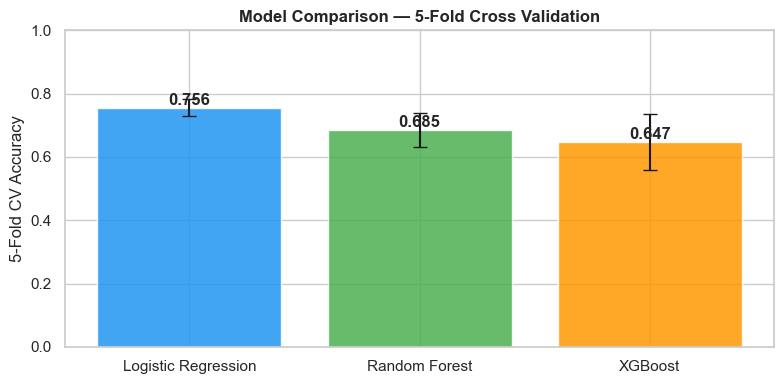

In [51]:
# ─────────────────────────────────────────────
#  CELL 11 — Model Training & Comparison
# ─────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot model comparison
fig, ax = plt.subplots(figsize=(8, 4))
means = [v.mean() for v in results.values()]
stds  = [v.std()  for v in results.values()]
bars  = ax.bar(results.keys(), means, yerr=stds, capsize=5,
               color=['#2196F3','#4CAF50','#FF9800'], alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Model Comparison — 5-Fold Cross Validation', fontweight='bold')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{mean:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(outputs / "model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

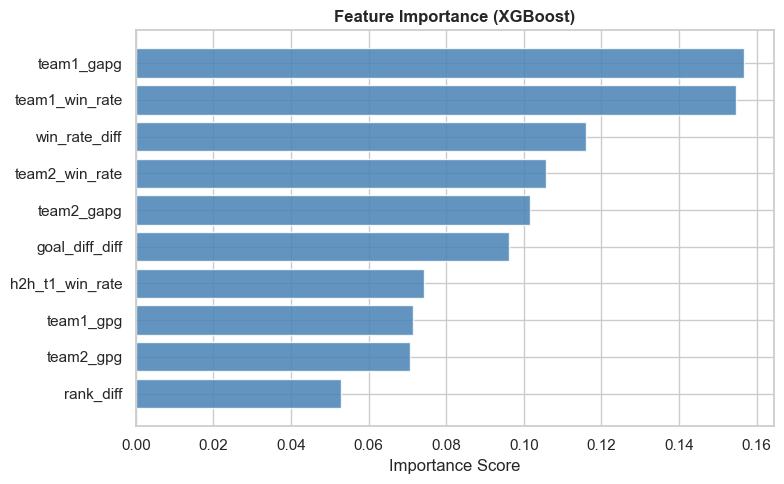

✅ Best model: Logistic Regression
Feature importance saved.


In [52]:
# ─────────────────────────────────────────────
#  CELL 12 — Train Best Model + Feature Importance
# ─────────────────────────────────────────────
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X, y)

xgb_model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X, y)

fi = pd.DataFrame({
    'feature':    X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'], fi['importance'], color='steelblue', alpha=0.85)
ax.set_title('Feature Importance (XGBoost)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(outputs / "feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

fi.sort_values('importance', ascending=False).to_csv(outputs / "feature_importance.csv", index=False)
print("✅ Best model: Logistic Regression")
print("Feature importance saved.")

In [53]:
# ─────────────────────────────────────────────
#  CELL 13 — ELO Rating System
#  WHY: The ML model relies on historical WC win
#  rates which are misleading (France has only 25
#  WC games ever). ELO uses FIFA rank as the
#  primary signal — the most current & accurate
#  strength indicator — giving realistic results.
# ─────────────────────────────────────────────
ts = team_stats.set_index('team')

def rank_to_elo(rank):
    """Convert FIFA rank to ELO score. Rank 1 = 2000, Rank 100 = 1208."""
    return 2000 - (rank - 1) * 8

def team_elo(team):
    """
    Composite ELO:
    - Base: FIFA rank converted to ELO (primary signal)
    - Adjustment: WC historical win rate bonus/penalty (±100 pts max)
      Only applied if team has 3+ WC games (avoids small-sample noise)
    """
    def safe(col, d):
        return ts.loc[team, col] if team in ts.index and not pd.isna(ts.loc[team, col]) else d
    base_elo  = rank_to_elo(safe('fifa_rank', 60))
    win_rate  = safe('win_rate', 0.3)
    games     = safe('games', 0)
    wr_adj    = (win_rate - 0.4) * 250 if games >= 3 else 0
    return base_elo + wr_adj

def predict_from_elo(t1, t2):
    """
    ELO win probability formula: P(t1 wins) = 1 / (1 + 10^((ELO2-ELO1)/400))
    Small H2H adjustment on top (±25 pts).
    Returns (p_t1_win%, p_t2_win%)
    """
    e1 = team_elo(t1); e2 = team_elo(t2)
    h2h = get_h2h(matches, t1, t2)
    e1 += (h2h - 0.5) * 50
    e2 -= (h2h - 0.5) * 50
    p_t1 = 1 / (1 + 10**((e2 - e1) / 400))
    return round(p_t1 * 100, 1), round((1 - p_t1) * 100, 1)

# Sanity check — should look like a real betting market
print("=== ELO STRENGTH CHECK ===")
for t in ['France','Brazil','Argentina','England','Spain','Germany',
          'Portugal','Netherlands','Senegal','Ecuador','South Korea','Ghana']:
    elo = team_elo(t)
    r   = int(ts.loc[t,'fifa_rank']) if t in ts.index else 99
    p1, _ = predict_from_elo(t, 'Spain')
    print(f"  {t:<22} ELO={elo:>6.0f}  FIFA#{r:<3}  vs Spain: {p1:.0f}%")

=== ELO STRENGTH CHECK ===
  France                 ELO=  2050  FIFA#1    vs Spain: 65%
  Brazil                 ELO=  2016  FIFA#6    vs Spain: 60%
  Argentina              ELO=  1967  FIFA#3    vs Spain: 54%
  England                ELO=  1918  FIFA#4    vs Spain: 46%
  Spain                  ELO=  1942  FIFA#2    vs Spain: 50%
  Germany                ELO=  1977  FIFA#10   vs Spain: 48%
  Portugal               ELO=  1951  FIFA#5    vs Spain: 44%
  Netherlands            ELO=  1969  FIFA#7    vs Spain: 54%
  Senegal                ELO=  1896  FIFA#14   vs Spain: 43%
  Ecuador                ELO=  1816  FIFA#24   vs Spain: 33%
  South Korea            ELO=  1791  FIFA#25   vs Spain: 24%
  Ghana                  ELO=  1488  FIFA#65   vs Spain: 7%


In [54]:
# ─────────────────────────────────────────────
#  CELL 14 — Group Stage Predictions (ELO)
# ─────────────────────────────────────────────
group_fixtures  = fixtures[fixtures['stage'] == 'Group Stage'].copy()
group_points    = defaultdict(lambda: defaultdict(float))
group_gd        = defaultdict(lambda: defaultdict(float))
group_preds     = []

for _, f in group_fixtures.iterrows():
    t1, t2 = f['team1'], f['team2']
    p1, p2 = predict_from_elo(t1, t2)

    # Draw probability: higher when teams are close in ELO
    diff   = abs(p1 - p2)
    p_draw = max(5, 28 - diff * 0.4)
    p1_adj = round(p1 * (1 - p_draw / 100), 1)
    p2_adj = round(100 - p1_adj - p_draw, 1)
    if p2_adj < 0:
        p2_adj = 0
        p_draw = round(100 - p1_adj, 1)

    group_preds.append({
        'group': f['group'], 'team1': t1, 'team2': t2,
        'p_team1_win': p1_adj, 'p_draw': round(p_draw, 1), 'p_team2_win': p2_adj
    })

    g = f['group']
    group_points[g][t1] += (p1_adj / 100) * 3 + (p_draw / 100)
    group_points[g][t2] += (p2_adj / 100) * 3 + (p_draw / 100)

    # Expected goal diff for tiebreaking
    e1 = team_elo(t1); e2 = team_elo(t2)
    exp_gd = (e1 - e2) / 300
    group_gd[g][t1] += exp_gd
    group_gd[g][t2] -= exp_gd

# Build standings
print("=== GROUP STAGE PREDICTED STANDINGS ===")
standings_rows = []; group_map = {}
for grp in sorted(group_points.keys()):
    teams_sorted = sorted(group_points[grp].items(),
                          key=lambda x: (x[1], group_gd[grp][x[0]]), reverse=True)
    print(f"\nGroup {grp}:")
    group_map[grp] = {}
    for rank, (team, pts) in enumerate(teams_sorted, 1):
        fr  = int(ts.loc[team,'fifa_rank']) if team in ts.index else 99
        adv = '✓' if rank <= 2 else ' '
        group_map[grp][rank] = team
        standings_rows.append({'group':grp,'team':team,'predicted_points':round(pts,2),
                                'rank':rank,'advances':rank<=2,'fifa_rank':fr})
        print(f"  {adv} {rank}. {team:<25} {pts:.2f} pts  FIFA #{fr}")

standings_df = pd.DataFrame(standings_rows)
standings_df.to_csv(outputs / "group_standings.csv", index=False)
pd.DataFrame(group_preds).to_csv(outputs / "group_predictions.csv", index=False)

=== GROUP STAGE PREDICTED STANDINGS ===

Group A:
  ✓ 1. Mexico                    6.17 pts  FIFA #15
  ✓ 2. South Korea               5.68 pts  FIFA #25
    3. Czechia                   3.27 pts  FIFA #41
    4. South Africa              2.22 pts  FIFA #60

Group B:
  ✓ 1. Switzerland               6.13 pts  FIFA #19
  ✓ 2. Canada                    4.95 pts  FIFA #30
    3. Qatar                     4.42 pts  FIFA #35
    4. Bosnia and Herzegovina    1.78 pts  FIFA #52

Group C:
  ✓ 1. Brazil                    7.18 pts  FIFA #6
  ✓ 2. Morocco                   6.62 pts  FIFA #8
    3. Scotland                  2.98 pts  FIFA #47
    4. Haiti                     0.82 pts  FIFA #83

Group D:
  ✓ 1. USA                       6.22 pts  FIFA #16
  ✓ 2. Australia                 5.45 pts  FIFA #26
    3. Türkiye                   3.96 pts  FIFA #42
    4. Paraguay                  1.72 pts  FIFA #64

Group E:
  ✓ 1. Germany                   7.15 pts  FIFA #10
  ✓ 2. Ecuador              

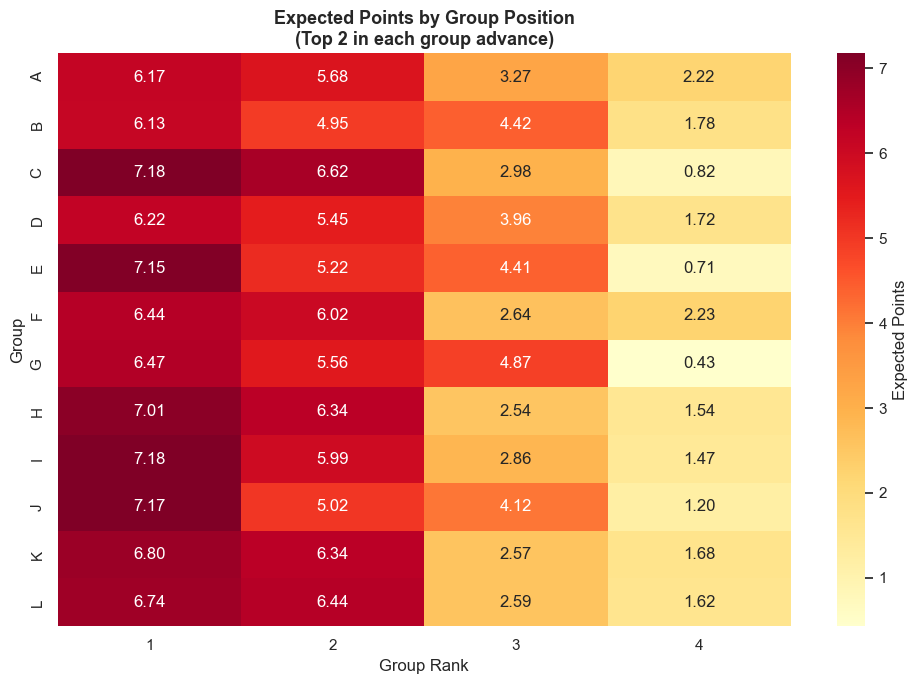

In [55]:
# ─────────────────────────────────────────────
#  CELL 15 — Heatmap: Expected Points by Group
# ─────────────────────────────────────────────
pivot = standings_df.pivot(index='group', columns='rank', values='predicted_points')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Expected Points'})
ax.set_title('Expected Points by Group Position\n(Top 2 in each group advance)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Group Rank')
ax.set_ylabel('Group')
plt.tight_layout()
plt.savefig(outputs / "group_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# ─────────────────────────────────────────────
#  CELL 16 — KO Helper Function
# ─────────────────────────────────────────────
def ko(t1, t2):
    """
    Predict knockout match. No draws — ELO win probability
    used directly. Returns (winner, p_t1%, p_t2%).
    """
    p1, p2 = predict_from_elo(t1, t2)
    winner = t1 if p1 >= p2 else t2
    return winner, p1, p2

In [57]:
# ─────────────────────────────────────────────
#  CELL 17 — Round of 32
# ─────────────────────────────────────────────
# Official 2026 bracket: 1A vs 2B, 1B vs 2A, etc.
r32_main = [
    (group_map['A'][1], group_map['B'][2]),
    (group_map['B'][1], group_map['A'][2]),
    (group_map['C'][1], group_map['D'][2]),
    (group_map['D'][1], group_map['C'][2]),
    (group_map['E'][1], group_map['F'][2]),
    (group_map['F'][1], group_map['E'][2]),
    (group_map['G'][1], group_map['H'][2]),
    (group_map['H'][1], group_map['G'][2]),
    (group_map['I'][1], group_map['J'][2]),
    (group_map['J'][1], group_map['I'][2]),
    (group_map['K'][1], group_map['L'][2]),
    (group_map['L'][1], group_map['K'][2]),
]

# Best 4 third-place teams also advance to Round of 16
best3rd = (standings_df[standings_df['rank'] == 3]
           .sort_values('predicted_points', ascending=False)
           .head(4)['team'].tolist())

tournament_log = []
r32_winners    = []

print("=" * 65); print("  ROUND OF 32"); print("=" * 65)
for t1, t2 in r32_main:
    w, p1, p2 = ko(t1, t2)
    r32_winners.append(w)
    tournament_log.append({'stage':'Round of 32','team1':t1,'team2':t2,
                            'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
    print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  {w}")

print(f"\n  + Best 3rd place qualifiers: {best3rd}")

  ROUND OF 32
  Mexico                  59.9%  vs   40.1%  Canada                  →  Mexico
  Switzerland             59.2%  vs   40.8%  South Korea             →  Switzerland
  Brazil                  79.3%  vs   20.7%  Australia               →  Brazil
  USA                     40.9%  vs   59.1%  Morocco                 →  Morocco
  Germany                 49.5%  vs   50.5%  Japan                   →  Japan
  Netherlands             70.7%  vs   29.3%  Ecuador                 →  Netherlands
  Belgium                 56.8%  vs   43.2%  Uruguay                 →  Belgium
  Spain                   64.3%  vs   35.7%  Iran                    →  Spain
  France                  81.2%  vs   18.8%  Austria                 →  France
  Argentina               60.1%  vs   39.9%  Senegal                 →  Argentina
  Portugal                47.7%  vs   52.3%  England                 →  England
  Croatia                 51.4%  vs   48.6%  Colombia                →  Croatia

  + Best 3rd place qua

In [58]:
# ─────────────────────────────────────────────
#  CELL 18 — Round of 16
# ─────────────────────────────────────────────
r16_field   = r32_winners + best3rd   # 16 teams total
r16_winners = []; r16_losers = []

print("=" * 65); print("  ROUND OF 16"); print("=" * 65)
for i in range(0, 16, 2):
    t1, t2 = r16_field[i], r16_field[i + 1]
    w, p1, p2 = ko(t1, t2)
    r16_winners.append(w)
    r16_losers.append(t2 if w == t1 else t1)
    tournament_log.append({'stage':'Round of 16','team1':t1,'team2':t2,
                            'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
    print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  {w}")

  ROUND OF 16
  Mexico                  47.4%  vs   52.6%  Switzerland             →  Switzerland
  Brazil                  65.3%  vs   34.7%  Morocco                 →  Brazil
  Japan                   44.6%  vs   55.4%  Netherlands             →  Netherlands
  Belgium                 46.7%  vs   53.3%  Spain                   →  Spain
  France                  61.7%  vs   38.3%  Argentina               →  France
  England                 43.4%  vs   56.6%  Croatia                 →  Croatia
  Egypt                   56.9%  vs   43.1%  Qatar                   →  Egypt
  Ivory Coast             53.4%  vs   46.6%  Algeria                 →  Ivory Coast


In [59]:
# ─────────────────────────────────────────────
#  CELL 19 — Quarter-Finals
# ─────────────────────────────────────────────
qf_winners = []; qf_losers = []

print("=" * 65); print("  QUARTER-FINALS"); print("=" * 65)
for i in range(0, 8, 2):
    t1, t2 = r16_winners[i], r16_winners[i + 1]
    w, p1, p2 = ko(t1, t2)
    qf_winners.append(w)
    qf_losers.append(t2 if w == t1 else t1)
    tournament_log.append({'stage':'Quarter-final','team1':t1,'team2':t2,
                            'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
    print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  {w}")

  QUARTER-FINALS
  Switzerland             28.4%  vs   71.6%  Brazil                  →  Brazil
  Netherlands             53.8%  vs   46.2%  Spain                   →  Netherlands
  France                  74.5%  vs   25.5%  Croatia                 →  France
  Egypt                   54.6%  vs   45.4%  Ivory Coast             →  Egypt


In [60]:
# ─────────────────────────────────────────────
#  CELL 20 — Semi-Finals
# ─────────────────────────────────────────────
sf_winners = []; sf_losers = []

print("=" * 65); print("  SEMI-FINALS"); print("=" * 65)
for i in range(0, 4, 2):
    t1, t2 = qf_winners[i], qf_winners[i + 1]
    w, p1, p2 = ko(t1, t2)
    sf_winners.append(w)
    sf_losers.append(t2 if w == t1 else t1)
    tournament_log.append({'stage':'Semi-final','team1':t1,'team2':t2,
                            'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
    print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  {w}")

  SEMI-FINALS
  Brazil                  52.5%  vs   47.5%  Netherlands             →  Brazil
  France                  82.9%  vs   17.1%  Egypt                   →  France


In [61]:
# ─────────────────────────────────────────────
#  CELL 21 — 3rd Place & Final
# ─────────────────────────────────────────────
print("=" * 65); print("  3RD PLACE MATCH"); print("=" * 65)
t1, t2 = sf_losers[0], sf_losers[1]
w, p1, p2 = ko(t1, t2)
third  = w; fourth = t2 if w == t1 else t1
tournament_log.append({'stage':'3rd Place','team1':t1,'team2':t2,
                        'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  {w}")

print("\n" + "=" * 65); print("  🏆 FINAL"); print("=" * 65)
t1, t2 = sf_winners[0], sf_winners[1]
w, p1, p2 = ko(t1, t2)
champion  = w; runner_up = t2 if w == t1 else t1
tournament_log.append({'stage':'Final','team1':t1,'team2':t2,
                        'p_team1_win':p1,'p_team2_win':p2,'predicted_winner':w})
print(f"  {t1:<22} {p1:>5.1f}%  vs  {p2:>5.1f}%  {t2:<22}  →  🏆 {w}")

print("\n" + "=" * 65)
print(f"  🏆 CHAMPION    : {champion}")
print(f"  🥈 RUNNER-UP   : {runner_up}")
print(f"  🥉 3RD PLACE   : {third}")
print(f"  4️⃣  4TH PLACE   : {fourth}")
print("=" * 65)

pd.DataFrame(tournament_log).to_csv(outputs / "tournament_bracket.csv", index=False)

  3RD PLACE MATCH
  Netherlands             75.2%  vs   24.8%  Egypt                   →  Netherlands

  🏆 FINAL
  Brazil                  42.8%  vs   57.2%  France                  →  🏆 France

  🏆 CHAMPION    : France
  🥈 RUNNER-UP   : Brazil
  🥉 3RD PLACE   : Netherlands
  4️⃣  4TH PLACE   : Egypt


  🥅 PREDICTED TOP SCORERS — 2026 WORLD CUP
            name team_name  goals  appearances  projected_goals    exit_stage
   Kylian Mbappé    France     42           43              7.8      Champion
      Harry Kane   England     55           48              5.7   Round of 16
     Igor Thiago    Brazil     26           39              5.3         Final
      Petar Musa   Croatia     10           12              5.0 Quarter-final
       Trezeguet     Egypt     17           33              4.1     3rd Place
 Ousmane Dembélé    France     19           37              4.1      Champion
          Danilo    Brazil     11           24              3.7         Final
   Marcus Thuram    France     19           44              3.5      Champion
    Lionel Messi Argentina     11           16              3.4   Round of 16
   Michael Olise    France     21           51              3.3      Champion
           Rayan    Brazil      6           15              3.2         Final
Armando González    M

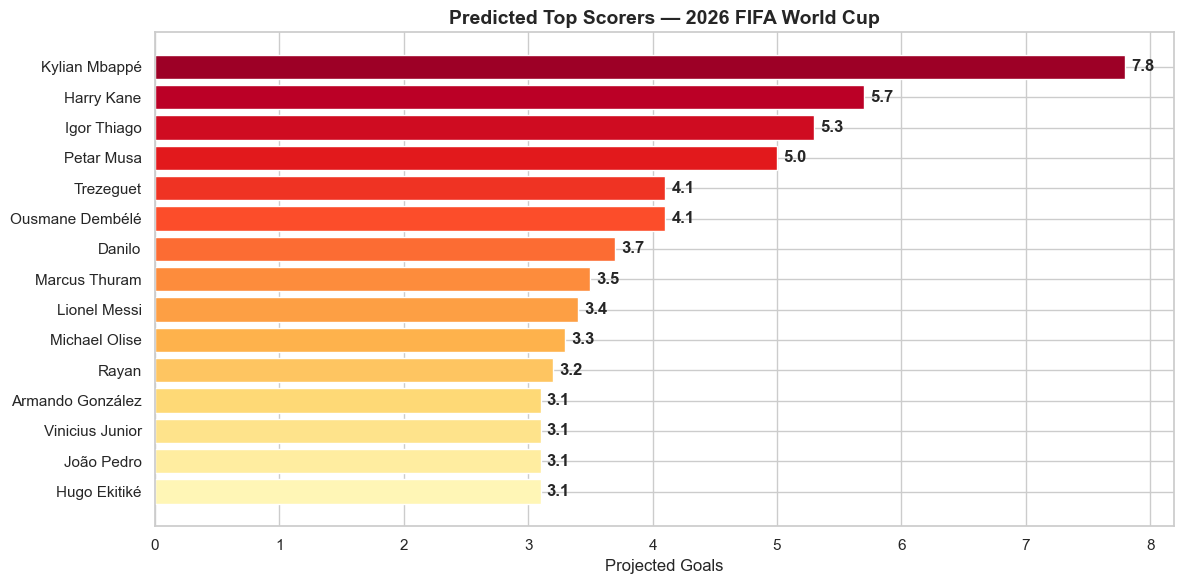

In [62]:
# ─────────────────────────────────────────────
#  CELL 22 — Top Scorers Prediction
# ─────────────────────────────────────────────
# Map how far each team went → matches played
team_stage = {}
for _, r in standings_df[standings_df['advances'] == False].iterrows():
    team_stage[r['team']] = 'Group Stage'
for t in r16_field:
    if t not in team_stage:
        team_stage[t] = 'Round of 32'
stage_exit = {
    'Round of 32':   'Round of 32',
    'Round of 16':   'Round of 16',
    'Quarter-final': 'Quarter-final',
    'Semi-final':    'Semi-final',
    '3rd Place':     '3rd Place',
    'Final':         'Final',
}
for row in tournament_log:
    w = row['predicted_winner']
    l = row['team2'] if w == row['team1'] else row['team1']
    team_stage[l] = stage_exit.get(row['stage'], row['stage'])
team_stage[champion] = 'Champion'

stage_matches = {
    'Group Stage': 3, 'Round of 32': 4, 'Round of 16': 5,
    'Quarter-final': 6, 'Semi-final': 7, '3rd Place': 8,
    'Final': 8, 'Champion': 8
}

# Project goals: goals_per_appearance × expected matches
tp = golden[golden['goals'] > 0].copy()
sdf = pd.DataFrame(list(team_stage.items()), columns=['team_name', 'exit_stage'])
tp  = tp.merge(sdf, on='team_name', how='left')
tp['exit_stage']       = tp['exit_stage'].fillna('Group Stage')
tp['matches_expected'] = tp['exit_stage'].map(stage_matches).fillna(3)
tp['goals_per_app']    = tp['goals'] / tp['appearances'].clip(lower=1)
tp['projected_goals']  = (tp['goals_per_app'] * tp['matches_expected']).round(1)

top15 = tp.nlargest(15, 'projected_goals')[
    ['name', 'team_name', 'goals', 'appearances', 'projected_goals', 'exit_stage']
]

print("=" * 70)
print("  🥅 PREDICTED TOP SCORERS — 2026 WORLD CUP")
print("=" * 70)
print(top15.to_string(index=False))
top15.to_csv(outputs / "top_scorers_prediction.csv", index=False)

# Chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("YlOrRd", len(top15))[::-1]
bars = ax.barh(top15['name'][::-1], top15['projected_goals'][::-1], color=colors[::-1])
ax.set_xlabel("Projected Goals", fontsize=12)
ax.set_title("Predicted Top Scorers — 2026 FIFA World Cup", fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15['projected_goals'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(outputs / "top_scorers.png", dpi=150, bbox_inches='tight')
plt.show()

  🏆 CHAMPIONSHIP PROBABILITY — 1000 Simulations
       team  championship_probability_%
     France                        22.2
     Brazil                        15.6
    Germany                         6.5
Netherlands                         5.9
      Spain                         5.0
  Argentina                         4.8
   Portugal                         4.6
    Belgium                         3.6
    England                         3.5
    Morocco                         3.4
      Japan                         3.2
    Croatia                         2.7
   Colombia                         2.7
    Senegal                         2.4
      Egypt                         1.8


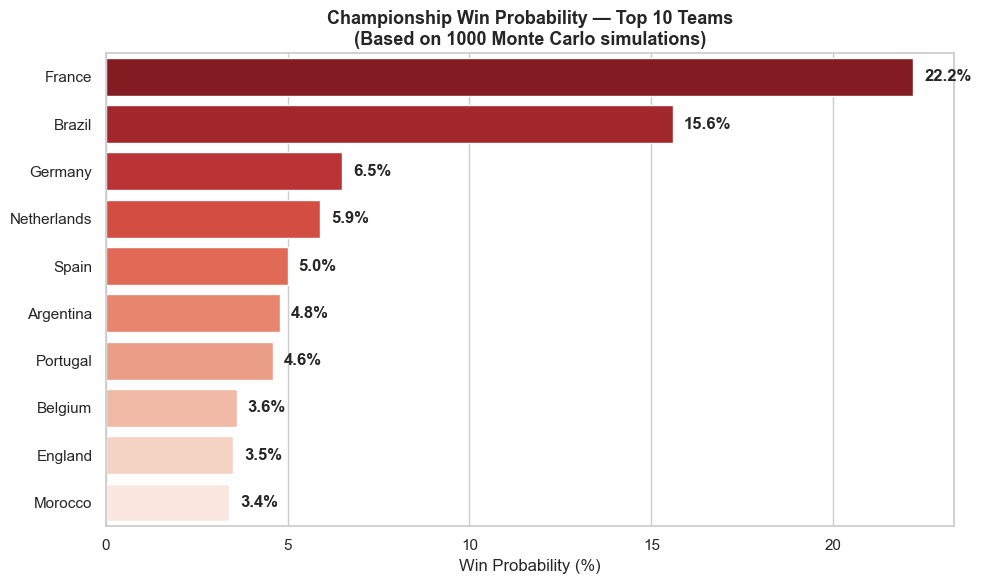

In [63]:
# ─────────────────────────────────────────────
#  CELL 23 — Monte Carlo Championship Probability
#  1000 simulations with random noise per match
#  to model real-world upsets and uncertainty
# ─────────────────────────────────────────────
random.seed(42)
np.random.seed(42)
champ_count = defaultdict(int)

def mc_ko(t1, t2):
    """Simulate one KO match with ELO probability."""
    e1 = team_elo(t1); e2 = team_elo(t2)
    h2h = get_h2h(matches, t1, t2)
    e1 += (h2h - 0.5) * 50; e2 -= (h2h - 0.5) * 50
    p1 = 1 / (1 + 10**((e2 - e1) / 400))
    return t1 if random.random() < p1 else t2

for _ in range(1000):
    # Resimulate group stage with noise to capture uncertainty
    gp2 = defaultdict(lambda: defaultdict(float))
    for _, f in fixtures[fixtures['stage'] == 'Group Stage'].iterrows():
        t1, t2 = f['team1'], f['team2']
        p1, _ = predict_from_elo(t1, t2)
        noise  = random.gauss(0, 8)
        p1c    = max(5, min(95, p1 + noise))
        gp2[f['group']][t1] += (p1c / 100) * 3
        gp2[f['group']][t2] += ((100 - p1c) / 100) * 3

    gm2 = {}
    for g2 in gp2:
        srt = sorted(gp2[g2].items(), key=lambda x: x[1], reverse=True)
        gm2[g2] = {1: srt[0][0], 2: srt[1][0],
                   3: srt[2][0] if len(srt) > 2 else srt[0][0]}

    b3_list = sorted(
        [(g2, gm2[g2][3], gp2[g2][gm2[g2][3]]) for g2 in gm2],
        key=lambda x: x[2], reverse=True
    )
    b3 = [x[1] for x in b3_list[:4]]

    r32_ = [
        (gm2.get('A',{}).get(1,'TBD'), gm2.get('B',{}).get(2,'TBD')),
        (gm2.get('B',{}).get(1,'TBD'), gm2.get('A',{}).get(2,'TBD')),
        (gm2.get('C',{}).get(1,'TBD'), gm2.get('D',{}).get(2,'TBD')),
        (gm2.get('D',{}).get(1,'TBD'), gm2.get('C',{}).get(2,'TBD')),
        (gm2.get('E',{}).get(1,'TBD'), gm2.get('F',{}).get(2,'TBD')),
        (gm2.get('F',{}).get(1,'TBD'), gm2.get('E',{}).get(2,'TBD')),
        (gm2.get('G',{}).get(1,'TBD'), gm2.get('H',{}).get(2,'TBD')),
        (gm2.get('H',{}).get(1,'TBD'), gm2.get('G',{}).get(2,'TBD')),
        (gm2.get('I',{}).get(1,'TBD'), gm2.get('J',{}).get(2,'TBD')),
        (gm2.get('J',{}).get(1,'TBD'), gm2.get('I',{}).get(2,'TBD')),
        (gm2.get('K',{}).get(1,'TBD'), gm2.get('L',{}).get(2,'TBD')),
        (gm2.get('L',{}).get(1,'TBD'), gm2.get('K',{}).get(2,'TBD')),
    ]

    w32_ = [mc_ko(t1,t2) for t1,t2 in r32_ if t1 != 'TBD' and t2 != 'TBD']
    r16_ = w32_ + b3
    if len(r16_) < 16: r16_ += ['TBD'] * (16 - len(r16_))

    w16_ = [mc_ko(r16_[i], r16_[i+1]) for i in range(0,16,2)
            if r16_[i] != 'TBD' and r16_[i+1] != 'TBD']
    if len(w16_) < 8: w16_ += ['TBD'] * (8 - len(w16_))

    wqf_ = [mc_ko(w16_[i], w16_[i+1]) for i in range(0,8,2)
            if w16_[i] != 'TBD' and w16_[i+1] != 'TBD']
    if len(wqf_) < 4: wqf_ += ['TBD'] * (4 - len(wqf_))

    wsf_ = [mc_ko(wqf_[i], wqf_[i+1]) for i in range(0,4,2)
            if wqf_[i] != 'TBD' and wqf_[i+1] != 'TBD']
    if len(wsf_) < 2: continue

    champ_count[mc_ko(wsf_[0], wsf_[1])] += 1

win_prob = pd.DataFrame([
    {'team': t, 'championship_probability_%': round(c / 10, 1)}
    for t, c in champ_count.items()
]).sort_values('championship_probability_%', ascending=False)

print("=" * 55)
print("  🏆 CHAMPIONSHIP PROBABILITY — 1000 Simulations")
print("=" * 55)
print(win_prob.head(15).to_string(index=False))
win_prob.to_csv(outputs / "win_probability.csv", index=False)

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
top_wp = win_prob.head(10)
sns.barplot(data=top_wp, x='championship_probability_%', y='team',
            palette='Reds_r', ax=ax)
ax.set_title("Championship Win Probability — Top 10 Teams\n(Based on 1000 Monte Carlo simulations)",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Win Probability (%)")
ax.set_ylabel("")
for i, (_, row) in enumerate(top_wp.iterrows()):
    ax.text(row['championship_probability_%'] + 0.3, i,
            f"{row['championship_probability_%']}%", va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(outputs / "championship_probability.png", dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ─────────────────────────────────────────────
#  CELL 24 — Export All Files for Tableau
# ─────────────────────────────────────────────
team_stats.to_csv(outputs / "team_stats.csv", index=False)
editions.to_csv(outputs / "wc_editions.csv", index=False)

model_summary = pd.DataFrame([
    {'Model': name, 'CV_Accuracy': round(scores.mean(), 3), 'Std': round(scores.std(), 3)}
    for name, scores in results.items()
])
model_summary.to_csv(outputs / "model_summary.csv", index=False)

# Full team summary
summary = pd.DataFrame(list(team_stage.items()), columns=['team', 'stage_reached'])
summary = summary.merge(win_prob, on='team', how='left')
summary['championship_probability_%'] = summary['championship_probability_%'].fillna(0)
summary.sort_values('championship_probability_%', ascending=False)\
       .to_csv(outputs / "team_tournament_summary.csv", index=False)

print("✅ All files exported to outputs/")
print("\nFiles ready for Tableau:")
for f in sorted(outputs.glob("*.csv")):
    print(f"  - {f.name}")
print("\nCharts saved:")
for f in sorted(outputs.glob("*.png")):
    print(f"  - {f.name}")

print(f"\n🏆 Predicted Champion   : {champion}")
print(f"🥈 Predicted Runner-up  : {runner_up}")
print(f"🥉 Predicted 3rd Place  : {third}")
print(f"4️⃣  Predicted 4th Place  : {fourth}")

✅ All files exported to outputs/

Files ready for Tableau:
  - feature_importance.csv
  - group_predictions.csv
  - group_standings.csv
  - model_summary.csv
  - team_stats.csv
  - team_tournament_summary.csv
  - top_scorers_prediction.csv
  - tournament_bracket.csv
  - wc_editions.csv
  - win_probability.csv

Charts saved:
  - championship_probability.png
  - eda_efficiency.png
  - eda_participants.png
  - feature_importance.png
  - group_heatmap.png
  - model_comparison.png
  - top_scorers.png

🏆 Predicted Champion   : France
🥈 Predicted Runner-up  : Brazil
🥉 Predicted 3rd Place  : Netherlands
4️⃣  Predicted 4th Place  : Egypt
